In [1]:
#Import Libraries

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

##Dimension reduction and clustering libraries
import umap
from umap import UMAP
import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist


In [2]:
#preprocessing 
dF=pd.read_csv("./preprocessed.csv")

In [3]:
dF['Numbering'] = range(1, len(dF) + 1)

# Display the DataFrame with the new column
print(dF)

          Protein UniProtID  \
0     BC11A_HUMAN    Q9H165   
1     BC11B_HUMAN    Q9C0K0   
2      BCL6_HUMAN    P41182   
3     BCL6B_HUMAN    Q8N143   
4      CTCF_HUMAN    P49711   
...           ...       ...   
1336  ZC3H8_HUMAN    Q8N5P1   
1337  ZGPAT_HUMAN    Q8N5A5   
1338  SATB1_HUMAN    Q01826   
1339   COE2_HUMAN    Q9HAK2   
1340   COE3_HUMAN    Q9H4W6   

                                               Sequence  Total AminoAcids  \
0     MSRRKQGKPQHLSKREFSPEPLEAILTDDEPDHGPLGAPEGDHDLL...               835   
1     MSRRKQGNPQHLSQRELITPEADHVEAAILEEDEGLEIEEPSGLGL...               894   
2     MASPADSCIQFTRHASDVLLNLNRLRSRDILTDVVIVVSREQFRAH...               706   
3     MGSPAAPEGALGYVREFTRHSSDVLGNLNELRLRGILTDVTLLVGG...               479   
4     MEGDAVEAIVEESETFIKGKERKTYQRRREGGQEEDACHLPQNQTD...               727   
...                                                 ...               ...   
1336  MDFENLFSKPPNPALGKTATDSDERIDDEIDTEVEETQEEKIKLEC...               291   
1337  MDEES

In [4]:
#considering only numericmns_to_exclude = ['Normalized HP Score','Total AminoAcids','Net Charge','Hydropaticity','K fraction','R fraction','f-','f+','sum_of_total_fractions','Numbering','total_aminoacids_count','f-','|f+ - f-|']
numeric_dF = dF.select_dtypes(include='number')
columns_to_exclude = ['Total AminoAcids','Net Charge','Hydropaticity','K fraction','R fraction','f-','sum_of_total_fractions','Numbering','total_aminoacids_count']
df = numeric_dF.drop(columns=columns_to_exclude)
df.head()
print(df.shape)

(1341, 21)


In [7]:
sns.set(style='white', context='poster', rc={'figure.figsize':(14,10)})

np.random.seed(42)
scaled_df = StandardScaler().fit_transform(df.values)
scaled_df

array([[-0.2199955 , -0.32634335, -0.19401391, ..., -1.02563006,
        -0.47297341, -0.42246529],
       [ 0.34499181,  0.2028925 , -0.18102521, ..., -1.11205889,
        -0.77795999, -0.51837915],
       [ 0.37663244,  0.24047173,  0.57100432, ...,  0.50442111,
        -0.35432605, -0.82931868],
       ...,
       [-0.04772969,  0.07123727, -1.29171579, ..., -0.06601627,
        -0.79323757, -0.65395385],
       [ 1.38611613, -0.24055157, -0.81797633, ...,  0.20047557,
        -0.87676637, -0.33483998],
       [ 1.44477472,  0.05099793, -0.76501795, ...,  0.11112966,
        -1.093008  , -0.62731291]])

In [8]:
# UMAP with 5 components
umap_model = umap.UMAP(n_components=5)
umap_embeddings = umap_model.fit_transform(scaled_df)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


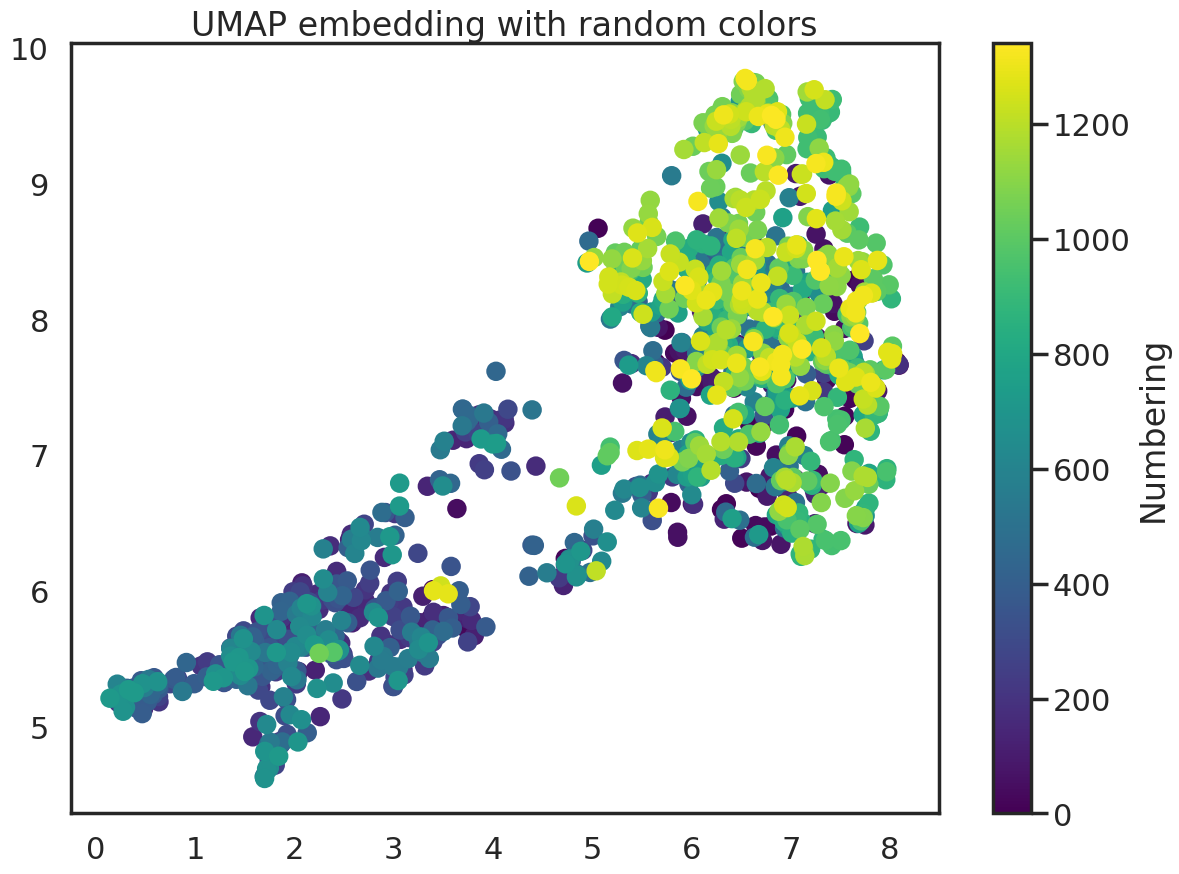

In [9]:
#PLOT UMAP RESULTS

color = df.index

plt.scatter(umap_embeddings[:,0],umap_embeddings[:,1],c=color,cmap='viridis')
plt.colorbar(label='Numbering')
plt.title('UMAP embedding with random colors')
plt.show()
